<a href="https://colab.research.google.com/github/LoveMachineX/-/blob/main/Game.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
import time

class MiniMotaEnv:
    def __init__(self):
        # Custom grid, using different numbers to represent different objects.
        # 0: empty space, 1: wall, 2: key, 3: door, 4: monster, 5: stairs, 6: health potion, 7: sword
        self.initial_grid = np.array([
            [1, 1, 1, 1, 1, 1, 1],
            [1, 0, 7, 0, 6, 0, 1],
            [1, 0, 2, 4, 0, 0, 1],
            [1, 1, 3, 1, 3, 1, 1],
            [1, 4, 0, 1, 6, 0, 1],
            [1, 6, 4, 6, 4, 5, 1],
            [1, 1, 1, 1, 1, 1, 1]
        ])
        self.grid = np.copy(self.initial_grid) # Initial grid copy

        # Origin position (Player)
        self.player_pos = [1, 1]

        # Player Attributes
        self.hp = 100          # health point
        self.attack = 10       # attack point
        self.has_key = False   # has key or not
        self.game_over = False
        self.reach_exit = False
        self.get_sword = False

        # Monster property
        self.monster_hp = 30   # monster's health point
        self.monster_attack = 5  # monster's attack point

    def reset(self):
        #Reset environment
        self.grid = np.copy(self.initial_grid)
        self.player_pos = [1, 1]
        self.hp = 100
        self.has_key = False
        self.game_over = False
        self.reach_exit = False
        self.get_sword = False
        return self._get_state()

    def _get_state(self):
        row, col = self.player_pos
        cell_type = self.grid[row, col]
        # state = (PositionX, PositionY, has key or not, current cell type, remaining health level)
        # Discretize the health points to prevent state explosion.
        hp_level = min(self.hp // 10, 10)  # divide 100 into 11 levels
        return (row, col, int(self.has_key), cell_type, hp_level)

    def step(self, action):
        #action: 0:up, 1:down, 2:left, 3:right
        if self.game_over or self.reach_exit:
            return self._get_state(), 0, True, {}

        # Take step
        row, col = self.player_pos
        new_row, new_col = row, col

        if action == 0:    # Up
            new_row -= 1
        elif action == 1:  # Down
            new_row += 1
        elif action == 2:  # Left
            new_col -= 1
        elif action == 3:  # Right
            new_col += 1

        # Hitting wall detection
        if self.grid[new_row, new_col] == 1:
            return self._get_state(), -1, False, {}  # punishment: -1 point for hitting wall

        # Update position
        self.player_pos = [new_row, new_col]
        cell_type = self.grid[new_row, new_col]
        reward = -0.1  # Given tiny punishment for moving, it will encourage agent to find the cloest path

        # Handle different cell types
        if cell_type == 2:  # key
            self.has_key = True
            self.grid[new_row, new_col] = 0  # pick key
            reward += 20
            print("Get key！")

        elif cell_type == 3:  # door
            if self.has_key:
                self.grid[new_row, new_col] = 0  # open the door
                reward += 30
                print("Open the door！")
            else:
                # No key, can not pass the door
                self.player_pos = [row, col]
                reward = -30
                print("Need key！")

        elif cell_type == 4:  # monster
            # Combat Settlement
            damage_to_monster = self.attack
            damage_to_player = max(0, self.monster_attack)

            if damage_to_monster >= self.monster_hp:
                # victory
                self.grid[new_row, new_col] = 0
                self.hp -= damage_to_player
                reward += 60
                print(f"Victory！Loss {damage_to_player} health points")
            else:
                # lose
                self.player_pos = [row, col]
                reward = -10
                print("Lose！")

            # Death
            if self.hp <= 0:
                self.game_over = True
                reward = -100
                print("Game Over！")

        elif cell_type == 5:  # Stair（Final point）
            self.reach_exit = True
            reward = 100
            print("Congratulations！")

        elif cell_type == 6:  # Health potion
            self.hp = min(100, self.hp + 20)
            self.grid[new_row, new_col] = 0
            reward += 15
            print(f"Get health potion！Current health points:{self.hp}")

        elif cell_type == 7: # Sword
            self.has_sword = True
            self.grid[new_row, new_col] = 0
            self.attack += 30
            reward += 15
            print("Get sword！Attack up!")

        return self._get_state(), reward, self.game_over or self.reach_exit, {}

    def render(self):
        # Display the current state of the game
        grid_display = self.grid.copy()
        r, c = self.player_pos
        # 8: player
        grid_display[r, c] = 8

        # Create a color mapping.
        fig, ax = plt.subplots(figsize=(5,5))
        cmap = plt.cm.tab10
        norm = plt.Normalize(0, 8)

        ax.imshow(grid_display, cmap=cmap, norm=norm, alpha=0.7)

        # Label
        for i in range(7):
            for j in range(7):
                val = grid_display[i, j]
                if val == 0:
                    text = '·'
                elif val == 1:
                    text = 'W' # wall
                elif val == 2:
                    text = 'K' # key
                elif val == 3:
                    text = 'D' # door
                elif val == 4:
                    text = 'M' # monster
                elif val == 5:
                    text = 'G' # goal(stair)
                elif val == 6:
                    text = 'P' # health potion
                elif val == 7:
                    text = "S" # sword
                elif val == 8:
                    text = 'A' # agent(player)
                else:
                    continue
                ax.text(j, i, text, ha='center', va='center', fontsize=15)

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"HP: {self.hp}, Key: {self.has_key}")
        plt.show()

In [8]:
class QLearningAgent:
    def __init__(self, state_size, action_size=4, learning_rate=0.1, discount=0.95, epsilon=0.3):
        self.action_size = action_size
        self.lr = learning_rate  # learning rate α
        self.gamma = discount    # discount factor γ
        self.epsilon = epsilon   # epsilon ε

        # Q-table：key:state， value:array of Q-values for each action.
        self.q_table = {}

    def get_q_values(self, state):
        if state not in self.q_table:
            # Initialize a new state with Q-values of 0 for all actions.
            self.q_table[state] = np.zeros(self.action_size)
        return self.q_table[state]

    def choose_action(self, state):
        # ε-greedy strategy for action selection
        if np.random.random() < self.epsilon:
            return np.random.randint(self.action_size)  # Exploration
        else:
            q_values = self.get_q_values(state)
            return np.argmax(q_values)  # Exploitation

    def learn(self, state, action, reward, next_state, done):
        q_values = self.get_q_values(state)
        next_q_values = self.get_q_values(next_state) if not done else np.zeros(self.action_size)

        # Q-learning update formula
        target = reward + self.gamma * np.max(next_q_values)
        q_values[action] += self.lr * (target - q_values[action])

In [9]:
# Initialize environment and agent.
env = MiniMotaEnv()
agent = QLearningAgent(state_size=None)

# Training parameters
episodes = 1000  # 训练500局
max_steps_per_episode = 100

# Recording the training process
rewards_history = []
success_history = []

# Training
for episode in range(episodes):
    state = env.reset()
    total_reward = 0

    # Decay the exploration rate
    agent.epsilon = max(0.01, 0.3 * (1 - episode / episodes))

    for step in range(max_steps_per_episode):
        # Choose action
        action = agent.choose_action(state)

        # Acting
        next_state, reward, done, _ = env.step(action)

        # Learning
        agent.learn(state, action, reward, next_state, done)

        total_reward += reward
        state = next_state

        if done:
            break

    # Recording result
    rewards_history.append(total_reward)
    success_history.append(1 if env.reach_exit else 0)

    # Log progress every 50 episodes.
    if (episode + 1) % 50 == 0:
        success_rate = np.mean(success_history[-50:])
        print(f"Episode {episode + 1}/{episodes}, Average Reward: {np.mean(rewards_history[-50:]):.1f}, Success Rate: {success_rate:.2%}")

Get sword！Attack up!
Get key！
Open the door！
Victory！Loss 5 health points
Get health potion！Current health points:100
Open the door！
Get sword！Attack up!
Get key！
Victory！Loss 5 health points
Get health potion！Current health points:100
Open the door！
Get health potion！Current health points:100
Open the door！
Get sword！Attack up!
Get key！
Open the door！
Victory！Loss 5 health points
Victory！Loss 5 health points
Get health potion！Current health points:100
Victory！Loss 5 health points
Get health potion！Current health points:100
Open the door！
Get sword！Attack up!
Get key！
Victory！Loss 5 health points
Get health potion！Current health points:100
Open the door！
Open the door！
Get sword！Attack up!
Get key！
Victory！Loss 5 health points
Get health potion！Current health points:100
Open the door！
Get health potion！Current health points:100
Get sword！Attack up!
Get key！
Victory！Loss 5 health points
Get health potion！Current health points:100
Open the door！
Open the door！
Get sword！Attack up!
Victor

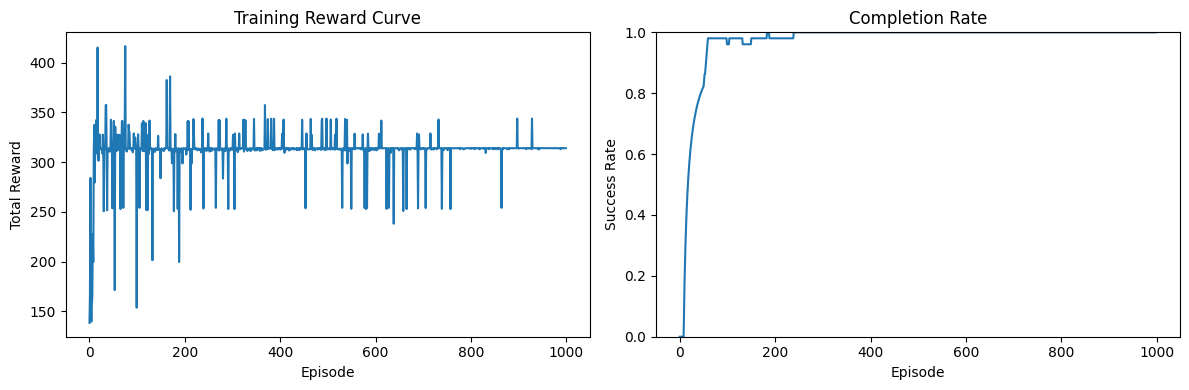

In [10]:
# Display learning curve
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(rewards_history)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Training Reward Curve')

plt.subplot(1, 2, 2)
# Compute the 50-episode moving average of the success rate.
success_rate = [np.mean(success_history[max(0, i-50):i+1]) for i in range(len(success_history))]
plt.plot(success_rate)
plt.xlabel('Episode')
plt.ylabel('Success Rate')
plt.title('Completion Rate')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

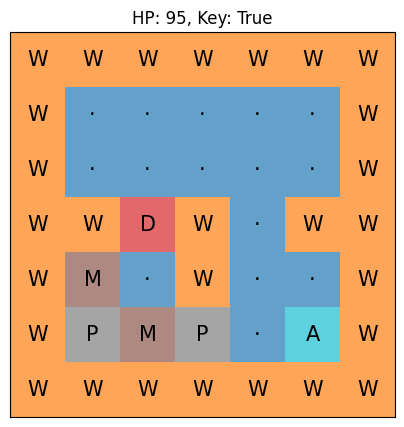

Step 10, Action: Right, Reward: 100
Congratulations！ Total Step: 10, Total Reward: 314.1


In [11]:
# Testing mode（no exploration）
agent.epsilon = 0

env = MiniMotaEnv() # Reinitialize the environment before testing
state = env.reset()
env.render()
time.sleep(1)

total_reward = 0
step_count = 0

while not env.game_over and not env.reach_exit and step_count < 30:
    # Agent choose action
    action = agent.choose_action(state)

    # Acting
    next_state, reward, done, _ = env.step(action)

    # Displayment
    display.clear_output(wait=True)
    env.render()
    print(f"Step {step_count+1}, Action: {['Up','Down','Left','Right'][action]}, Reward: {reward}")
    time.sleep(1)

    state = next_state
    total_reward += reward
    step_count += 1

if env.reach_exit:
    print(f"Congratulations！ Total Step: {step_count}, Total Reward: {total_reward}")
else:
    print(f"Test failed. You are lost.")